# Demand Forecasting Analysis

## Objective

Demand forecasting is essential for supply chain planning.

In this section we:

* Analyze historical demand patterns  
* Train a forecasting model  
* Predict future demand for the next 90 days

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../"))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.forecasting_model import (
    prepare_demand_data,
    train_test_split,
    train_forecast_model,
    predict_future,
    evaluate_forecast
)

In [3]:
df = pd.read_parquet("../data/processed/clean_supply_chain.parquet")

# Prepare Demand Time Series

In [4]:
demand_df = prepare_demand_data(df)

demand_df.head()

,ds,y
0,2015-01-25,2731.000000
1,2015-02-01,2655.000000
2,2015-02-08,2646.666667
3,2015-02-22,2657.000000
4,2015-03-01,2740.000000


# Split Data

In [5]:
train, test = train_test_split(demand_df)

# Train Forecast Model

In [6]:
model = train_forecast_model(train)

03:05:25 - cmdstanpy - INFO - Chain [1] start processing
03:05:25 - cmdstanpy - INFO - Chain [1] done processing


# Evaluation

In [7]:
forecast = predict_future(model, periods=len(test), freq="W")
mae, rmse, merged = evaluate_forecast(forecast, test)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 40.398022230089936
RMSE: 44.01616700397993


In [8]:
def smape(merged_df):
    y_true = merged_df["y"]
    y_pred = merged_df["yhat"]

    denominator = (abs(y_true) + abs(y_pred)) / 2
    mask = denominator != 0

    return (abs(y_pred[mask] - y_true[mask]) / denominator[mask]).mean() * 100

print("SMAPE:", smape(merged))

SMAPE: 1.5939251876964922


## Model Evaluation

Here’s how the model performed:

- **MAE:** 40.40  
- **RMSE:** 44.02  
- **SMAPE:** 1.59%  

### What this means

On average, the model is off by about **40 units** when predicting demand. Considering that demand is usually around **2400–2600 units**, this is a pretty small difference.

The RMSE is very close to the MAE, which means the model isn’t making large mistakes — its errors are fairly consistent.

The SMAPE is around **1.6%**, which shows that the predictions are very close to the actual values in percentage terms.

### Overall

The model does a **good job of capturing demand patterns** and provides reliable forecasts. While it’s not perfect, the error is small enough to make it useful for understanding trends and supporting decisions.

# Visualization

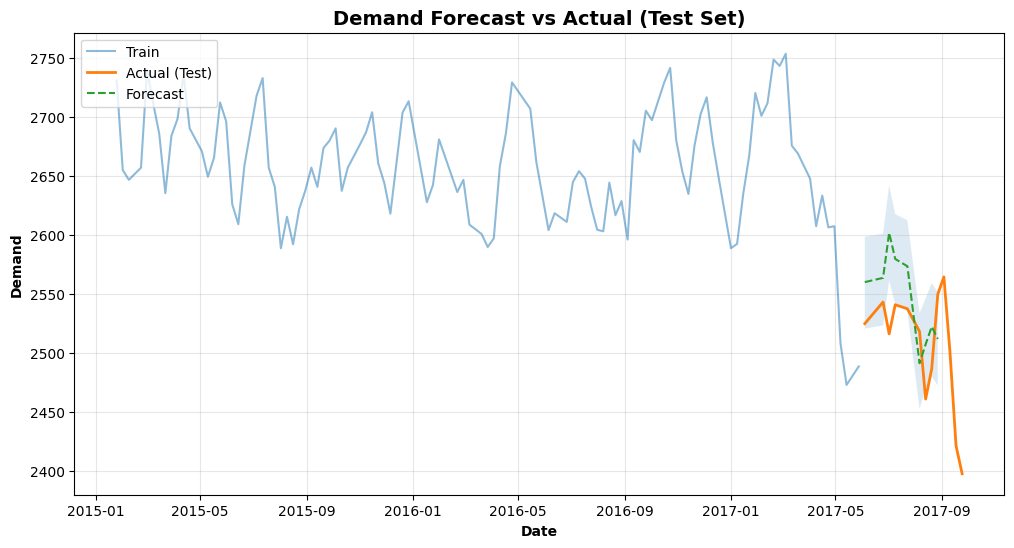

In [9]:
plt.figure(figsize=(12,6))

# Train data
plt.plot(train["ds"], train["y"], label="Train", alpha=0.5)

# Test actual
plt.plot(test["ds"], test["y"], label="Actual (Test)", linewidth=2)

# Forecast aligned with test dates
test_forecast = merged

# Forecast line
plt.plot(test_forecast["ds"], test_forecast["yhat"], label="Forecast", linestyle="--")

# Confidence interval
plt.fill_between(
    test_forecast["ds"],
    test_forecast["yhat_lower"],
    test_forecast["yhat_upper"],
    alpha=0.15
)

plt.legend(loc="upper left")
plt.title("Demand Forecast vs Actual (Test Set)", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontweight="bold")
plt.ylabel("Demand", fontweight="bold")
plt.grid(alpha=0.3)
plt.show()

# Future Forecast

03:05:33 - cmdstanpy - INFO - Chain [1] start processing
03:05:33 - cmdstanpy - INFO - Chain [1] done processing


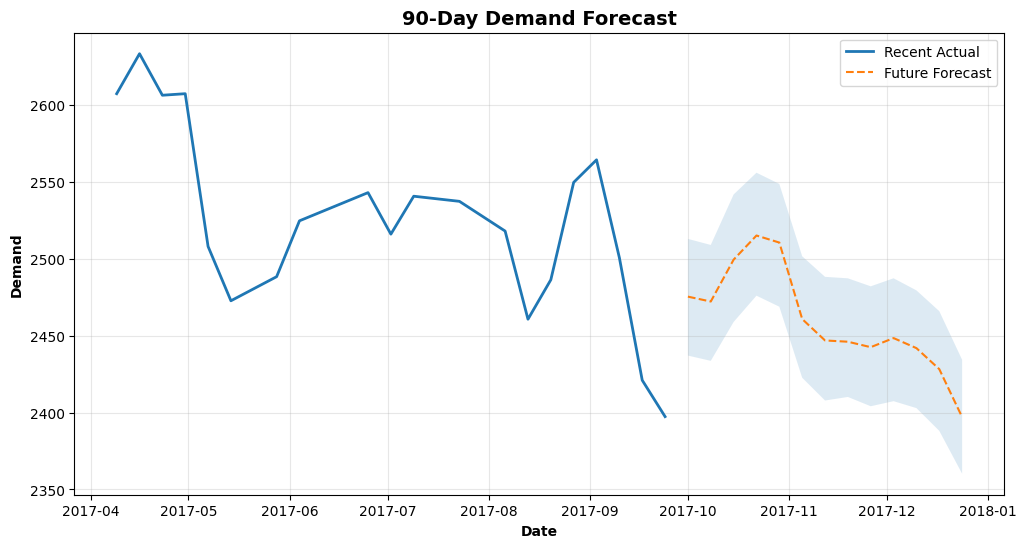

In [10]:
full_model = train_forecast_model(demand_df)
future_forecast = predict_future(full_model, periods=13, only_future=True)  # 13 weeks ≈ 90 days

plt.figure(figsize=(12,6))

# Add recent actual data for context
plt.plot(
    demand_df["ds"].tail(20),
    demand_df["y"].tail(20),
    label="Recent Actual",
    linewidth=2
)

# Forecast line
plt.plot(
    future_forecast["ds"],
    future_forecast["yhat"],
    label="Future Forecast",
    linestyle="--"
)

# Confidence interval
plt.fill_between(
    future_forecast["ds"],
    future_forecast["yhat_lower"],
    future_forecast["yhat_upper"],
    alpha=0.15
)

plt.legend()
plt.title("90-Day Demand Forecast", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontweight="bold")
plt.ylabel("Demand", fontweight="bold")
plt.grid(alpha=0.3)
plt.show()

<Axes: title={'center': 'Recent Demand Trend'}, xlabel='ds'>

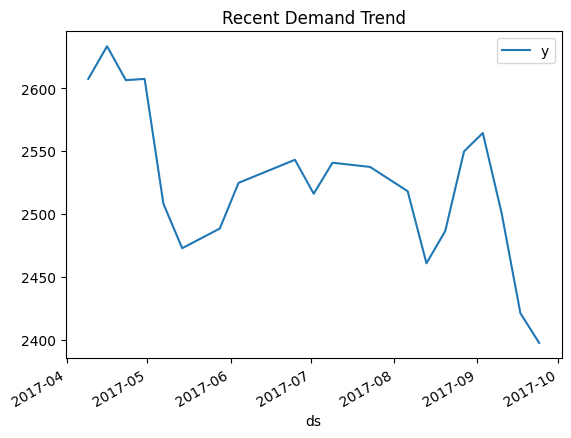

In [12]:
demand_df.tail(20).plot(x="ds", y="y", title="Recent Demand Trend")

### Recent Demand Behavior

To better understand the forecast trend, we examine the most recent demand values. This helps explain why the model predicts a slight decline.

## Forecast Insights

### Overall Trend
The forecast suggests that demand may **slightly decrease over the next 90 days**, dropping from around 2500 units to about 2400 units. However, this change is gradual rather than sharp.

---

### What’s Happening in the Short Term
In the near future, demand is expected to **move up and down a bit**, which is normal. The model doesn’t predict any extreme spikes or crashes, just regular fluctuations.

---

### Why the Forecast is Dropping
This downward trend is mainly influenced by a **recent dip in demand** seen in the latest data. The model is picking up on that and projecting it forward.

---

### How Reliable is This?
The forecast includes a range (confidence interval), and this range gets wider over time. This means the predictions are **more reliable in the short term**, but less certain further into the future.

---

### Understanding the Pattern
Looking at past data, demand doesn’t follow a strict upward or downward trend. Instead, it tends to **go up and down over time**, so the current decline might just be part of that pattern rather than a long-term drop.

---

### What This Means for the Business
The slight decline in demand could be due to:
- Temporary changes or short-term fluctuations  
- Seasonal effects  
- Normal variability in customer behavior  

---

### Final Thoughts
This forecast is useful as a **general direction**, but it shouldn’t be taken as an exact prediction. It’s best to keep monitoring the data and adjust decisions as new information comes in.